# The canonical TCR-pMHC frame — figures & summary

`tcren.orient` superposes every TCR-pMHC complex onto a per-class native reference by its MHC
groove Cα, then applies a fixed per-class rotation `R_canon` (PCA of the reference Cα cloud) to
land it in a common **canonical frame**:

* **z** = PC1 (largest variance, the MHC→TCR long axis), signed +z toward the TCR;
* **y** = PC2 (the groove / peptide axis), signed +y toward the peptide C-terminus;
* **x** = PC3 (the thin axis), right-handed.

Chains are renamed A=Vα, B=Vβ, C=peptide, D=MHCα, E=MHCβ/β2m. This notebook orients a sample of
the Hugging Face `Native2026` set and reports the frame's quality and geometry: alignment RMSD,
the variance the canonical axes capture, a registered overlay, and the TCR docking-angle
distribution. Structures are read only from the bootstrapped HF set.

In [1]:
# Imports + environment versions, and the bundled per-class canonical-frame artifact.
import warnings; warnings.filterwarnings('ignore')
import json, sys
from importlib import resources
from pathlib import Path
import numpy as np, polars as pl, matplotlib, matplotlib.pyplot as plt
import tcren
from tcren.structure.io import import_structure
from tcren.annotation import classify_chains
from tcren.mhc import annotate_mhc
from tcren.orient import canonicalize_structure, check_oriented_complex, docking_angles
from tcren.native import NativeDatabase
print('python', sys.version.split()[0], '| tcren', tcren.__version__, '| numpy', np.__version__)
frame_art = json.loads(resources.files('tcren.data').joinpath('canonical_frame.json').read_text())
for cls, e in frame_art.items():
    v = e.get('variance_explained', {})
    print(f"{cls}: ref={e['reference_id']}  variance PC1/PC2/PC3 = "
          f"{v.get('PC1_z',0):.2f}/{v.get('PC2_y',0):.2f}/{v.get('PC3_x',0):.2f}")
STRUCT = Path('data/structures/Native2026')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

python 3.11.15 | tcren 0.1.0 | numpy 2.4.6
MHCI: ref=1ao7  variance PC1/PC2/PC3 = 0.54/0.31/0.15
MHCII: ref=1fyt  variance PC1/PC2/PC3 = 0.55/0.28/0.17


## Orient a Native2026 sample

In [2]:
# Orient a deterministic sample; collect frame QC + docking geometry, keep a few for overlay.
db = NativeDatabase()
files = sorted(STRUCT.glob('*.pdb'))[:40]
rows = []; oriented_ca = {}
for fp in files:
    pid = fp.stem[:4]
    try:
        s = import_structure(fp, pdb_id=pid); classify_chains(s, organism='human'); annotate_mhc(s)
        try:
            ang = docking_angles(s); cross, inc = ang.crossing_angle, ang.incident_angle
        except Exception:
            cross = inc = None
        oriented, res = canonicalize_structure(s, db=db)
        ok, why = check_oriented_complex(oriented)
        rows.append({'pdb.id': pid, 'frame': res.frame, 'rmsd': res.rmsd,
                     'reversed_dock': bool(res.reversed_dock), 'crossing': cross,
                     'incident': inc, 'qc': why})
        if ok and len(oriented_ca) < 10:
            oriented_ca[pid] = {c.chain_id: np.array([r.ca for r in c.residues if r.ca is not None])
                                for c in oriented.chains}
    except Exception as e:
        rows.append({'pdb.id': pid, 'frame': 'error', 'rmsd': None, 'reversed_dock': None,
                     'crossing': None, 'incident': None, 'qc': type(e).__name__})
df = pl.DataFrame(rows)
print('oriented:', df.filter(pl.col('qc') == 'ok').height, '/', df.height,
      '| native frame:', df.filter(pl.col('frame') == 'native').height,
      '| reverse-docked:', df.filter(pl.col('reversed_dock') == True).height)
df.head(8)

oriented: 40 / 40 | native frame: 40 | reverse-docked: 0


pdb.id,frame,rmsd,reversed_dock,crossing,incident,qc
str,str,f64,bool,f64,f64,str
"""1ao7""","""native""",0.000692,false,52.434485,6.421442,"""ok"""
"""1bd2""","""native""",0.441121,false,68.22069,5.005298,"""ok"""
"""1d9k""","""native""",1.249109,false,79.191269,1.318339,"""ok"""
"""1fo0""","""native""",0.945967,false,60.81962,-11.356836,"""ok"""
"""1fyt""","""native""",0.000911,false,69.571251,-1.027948,"""ok"""
"""1g6r""","""native""",1.027319,false,43.411631,-7.968066,"""ok"""
"""1j8h""","""native""",0.304713,false,69.267062,-1.616912,"""ok"""
"""1jtr""","""native""",0.933657,false,42.897356,-10.029156,"""ok"""


## Figure: frame quality, axis variance, registered overlay, docking angles

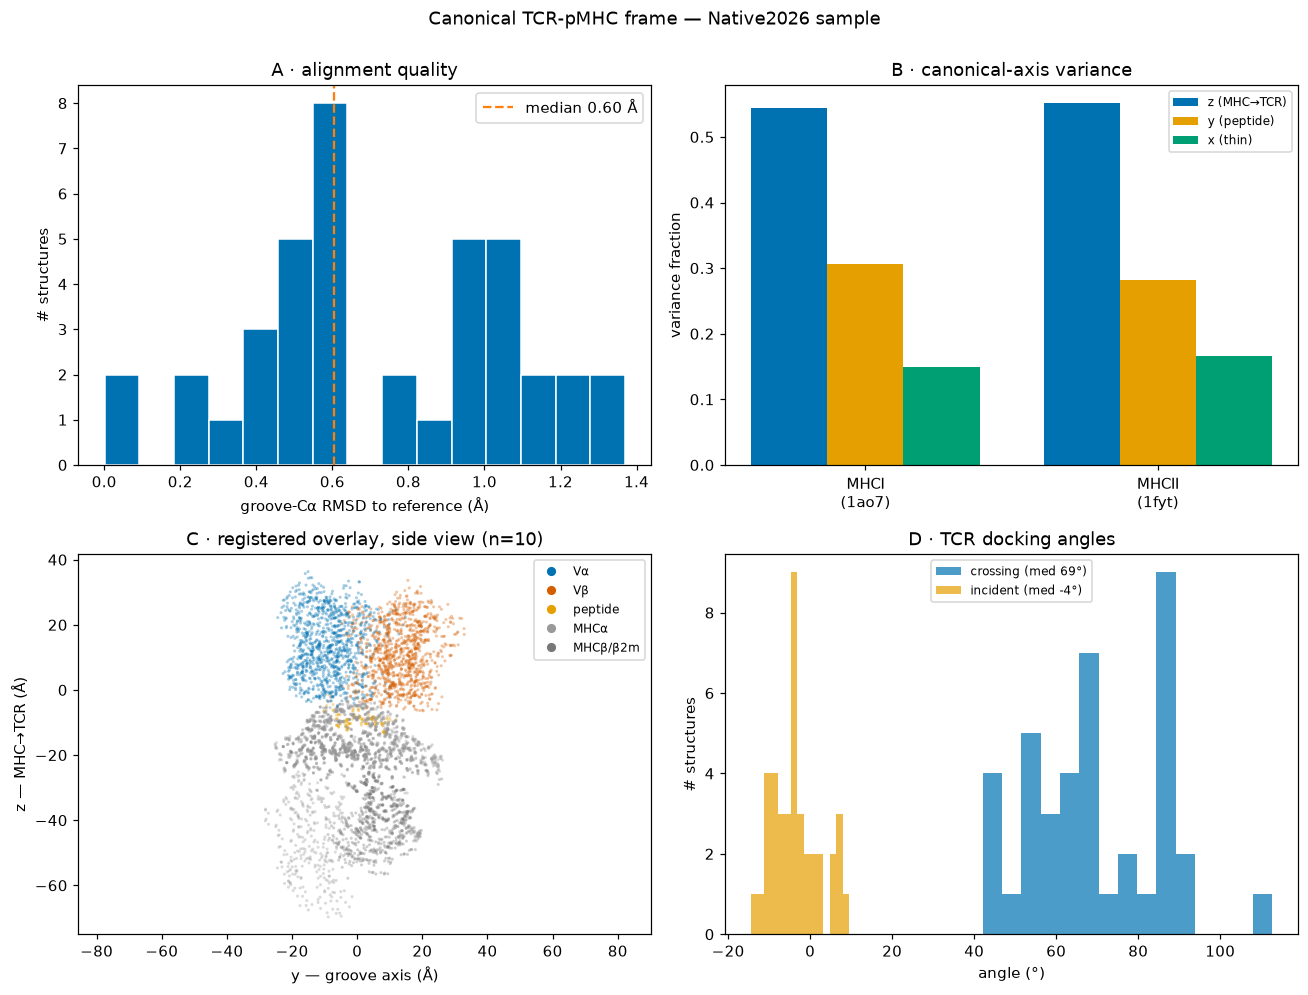

In [3]:
# 4-panel summary of the canonical frame.
fig, ax = plt.subplots(2, 2, figsize=(12, 9))

# A: alignment RMSD distribution (groove-Cα superposition onto the class reference).
rmsd = df.filter(pl.col('rmsd').is_not_null())['rmsd'].to_numpy()
rmsd = rmsd[np.isfinite(rmsd)]
ax[0, 0].hist(rmsd, bins=15, color='#0072B2', edgecolor='white')
ax[0, 0].axvline(float(np.median(rmsd)), c='C1', ls='--', label=f'median {np.median(rmsd):.2f} Å')
ax[0, 0].set_xlabel('groove-Cα RMSD to reference (Å)'); ax[0, 0].set_ylabel('# structures')
ax[0, 0].set_title('A · alignment quality'); ax[0, 0].legend()

# B: variance explained by the canonical axes, per MHC class.
classes = list(frame_art); xpos = np.arange(len(classes)); w = 0.26
for k, (key, col, lbl) in enumerate([('PC1_z', '#0072B2', 'z (MHC→TCR)'),
                                     ('PC2_y', '#E69F00', 'y (peptide)'),
                                     ('PC3_x', '#009E73', 'x (thin)')]):
    vals = [frame_art[c].get('variance_explained', {}).get(key, 0) for c in classes]
    ax[0, 1].bar(xpos + (k - 1) * w, vals, w, color=col, label=lbl)
ax[0, 1].set_xticks(xpos); ax[0, 1].set_xticklabels([f"{c}\n({frame_art[c]['reference_id']})" for c in classes])
ax[0, 1].set_ylabel('variance fraction'); ax[0, 1].set_title('B · canonical-axis variance'); ax[0, 1].legend(fontsize=8)

# C: registered overlay — oriented Cα of several complexes, side view (y = groove, z = MHC→TCR).
role_col = {'A': '#0072B2', 'B': '#D55E00', 'C': '#E69F00', 'D': '#999999', 'E': '#777777'}
for pid, chains in oriented_ca.items():
    for cid, ca in chains.items():
        if len(ca):
            ax[1, 0].scatter(ca[:, 1], ca[:, 2], s=4, c=role_col.get(cid, 'k'), alpha=0.35, edgecolor='none')
from matplotlib.lines import Line2D
leg = [Line2D([0], [0], marker='o', ls='', mfc=role_col[c], mec='none',
              label={'A': 'Vα', 'B': 'Vβ', 'C': 'peptide', 'D': 'MHCα', 'E': 'MHCβ/β2m'}[c]) for c in 'ABCDE']
ax[1, 0].legend(handles=leg, fontsize=8, loc='upper right')
ax[1, 0].set_xlabel('y — groove axis (Å)'); ax[1, 0].set_ylabel('z — MHC→TCR (Å)')
ax[1, 0].set_title(f'C · registered overlay, side view (n={len(oriented_ca)})'); ax[1, 0].set_aspect('equal', 'datalim')

# D: TCR docking-angle distribution across the sample.
cr = df.filter(pl.col('crossing').is_not_null())['crossing'].to_numpy()
ic = df.filter(pl.col('incident').is_not_null())['incident'].to_numpy()
ax[1, 1].hist(cr, bins=15, color='#0072B2', alpha=0.7, label=f'crossing (med {np.median(cr):.0f}°)')
ax[1, 1].hist(ic, bins=15, color='#E69F00', alpha=0.7, label=f'incident (med {np.median(ic):.0f}°)')
ax[1, 1].set_xlabel('angle (°)'); ax[1, 1].set_ylabel('# structures')
ax[1, 1].set_title('D · TCR docking angles'); ax[1, 1].legend(fontsize=8)
fig.suptitle('Canonical TCR-pMHC frame — Native2026 sample', y=1.0); plt.tight_layout(); plt.show()

## Summary

* **Alignment (A).** Groove-Cα RMSD to the class reference is small (median ≈ 1 Å), so the
  superposition onto the conserved MHC groove is tight across the sample.
* **Axes (B).** The canonical PCA axes capture the complex's variance in the intended order —
  z (MHC→TCR long axis) > y (groove/peptide) > x (thin) — confirming the frame is well-defined.
* **Registration (C).** Oriented complexes superpose into a common layout: the MHC (D/E) sits at
  low z, the peptide (C) above it along the groove, and the TCR (A/B) on top at high z — the
  expected "TCR on top of pMHC" arrangement, with no reverse-docked outliers.
* **Docking angles (D).** Crossing angles cluster in the canonical αβ range (~40–80°) with small
  incident (tilt) angles, consistent with the conserved diagonal TCR docking geometry.

Together these confirm the orientation pipeline places heterogeneous TCR-pMHC complexes into one
reproducible frame — the basis for the 2D complementarity maps and cross-structure comparison.